## Load Dataset

In [2]:
import kagglehub

path = kagglehub.dataset_download("uciml/default-of-credit-card-clients-dataset")
print("Dataset path:", path)

Using Colab cache for faster access to the 'default-of-credit-card-clients-dataset' dataset.
Dataset path: /kaggle/input/default-of-credit-card-clients-dataset


In [3]:
import os

print(os.listdir(path))

['UCI_Credit_Card.csv']


In [4]:
import pandas as pd

file = os.path.join(path, "UCI_Credit_Card.csv")
df = pd.read_csv(file)
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


## Experiment 0: Data Undertanding

In [5]:
print("Number of rows    :", df.shape[0])
print("Number of columns :", df.shape[1])

Number of rows    : 30000
Number of columns : 25


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   300

In [7]:
df.describe()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


In [21]:
missing = df.isnull().sum()
missing[missing > 0]

,0


In [20]:
print("Total duplicate:", df.duplicated().sum())
print("Number of unique ID:", df["ID"].nunique())

Total duplicate: 0
Number of unique ID: 30000


default.payment.next.month
0    23364
1     6636
Name: count, dtype: int64

default.payment.next.month
0    77.88
1    22.12
Name: proportion, dtype: float64


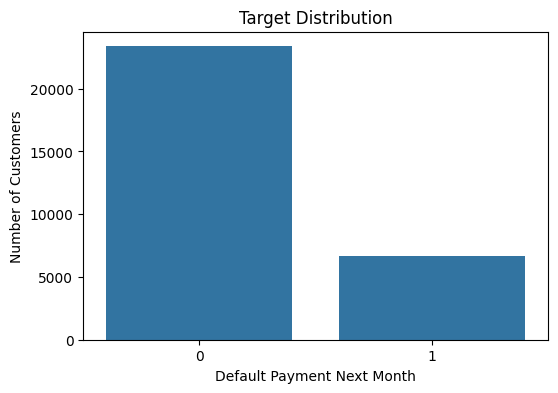

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

target_col = "default.payment.next.month"

print(df[target_col].value_counts())
print()
print(df[target_col].value_counts(normalize=True) * 100)

plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x=target_col
)

plt.title("Target Distribution")
plt.xlabel("Default Payment Next Month")
plt.ylabel("Number of Customers")

plt.show()

,Lower Bound,Upper Bound,Outliers Count,Percentage
LIMIT_BAL,-235000.000,525000.000,167.0,0.556667
AGE,8.500,60.500,272.0,0.906667
BILL_AMT1,-91739.625,162389.375,2400.0,8.000000
PAY_AMT1,-5009.000,11015.000,2745.0,9.150000


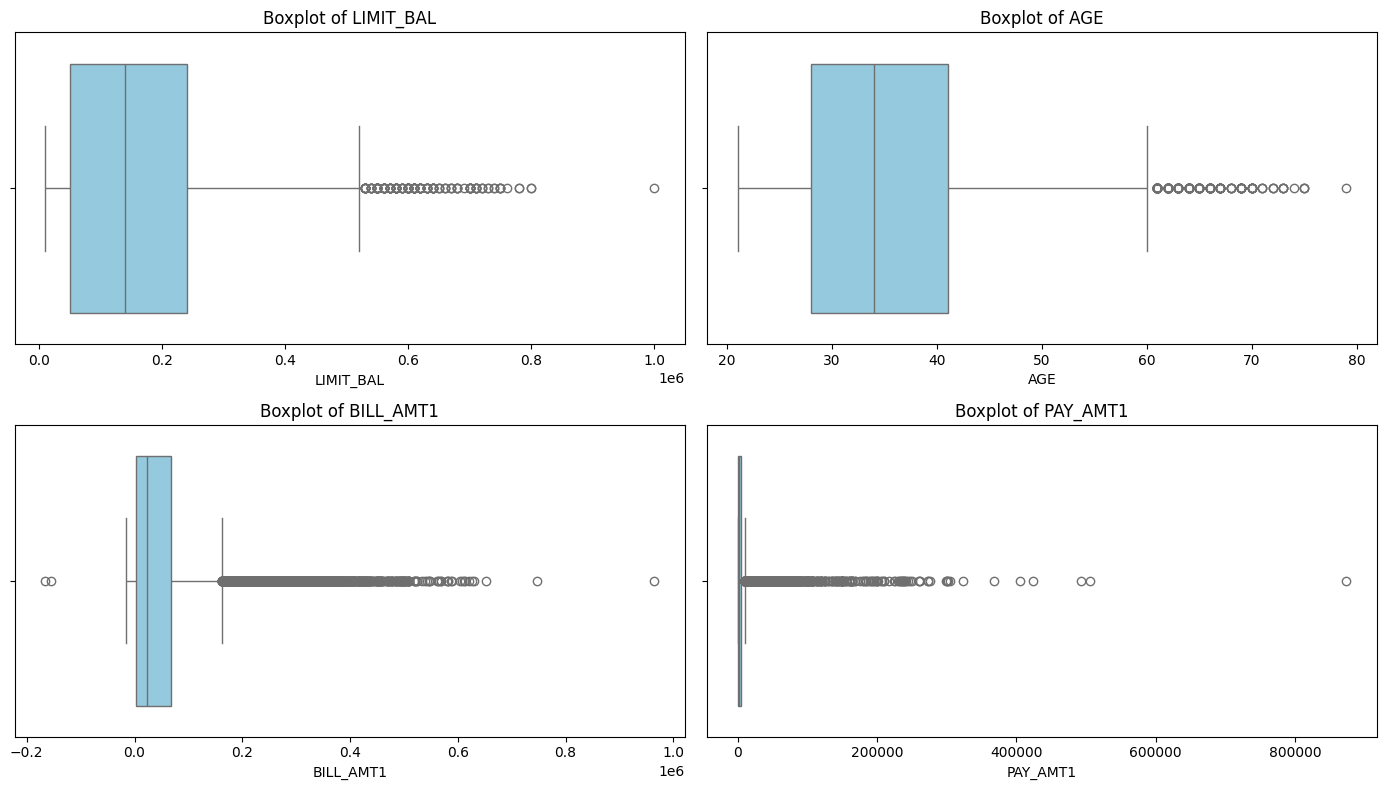

In [23]:
num_cols = ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'PAY_AMT1']
outlier_summary = {}
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_summary[col] = {
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Outliers Count': len(outliers),
        'Percentage': (len(outliers) / len(df)) * 100
    }

outlier_df = pd.DataFrame(outlier_summary).T
display(outlier_df)

plt.figure(figsize=(14, 8))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(data=df, x=col, color='skyblue')
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

**Interpretasi Experiment 0**

Experiment 0 dilakukan guna mengetahui gambaran data secara deskriptif. Tidak ditemukan adanya mising value, maupun duplikasi, namun ditemukan adanya outlier yang cukup signifikan. Outlier ini tidak langsung dihilangkan karena ke-4 variabel yang mengandung outlier tersebut masing-masing menyimpan informasi pentingg yang merepresentasikan karakteristik tiap nasabah, yaitu seberapa besar bill yang ditagihkan dan seberapa banyak bill yang dibayar oleh nasabah tersebut.


### Splitting

In [26]:
X = df.drop(columns=[target_col, "ID"])
y = df[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (30000, 23)
y shape: (30000,)


In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=1312, stratify=y)

## Experiment 1: Baseline Model

In [33]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import StratifiedKFold, cross_val_score

def evaluate_model(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=12
    )

    cv_scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="f1"
    )

    cv_f1 = cv_scores.mean()

    return {
        "CV F1": cv_f1,
        "Test Accuracy": accuracy,
        "Test Precision": precision,
        "Test Recall": recall,
        "Test F1": f1
    }

In [34]:
from sklearn.linear_model import LogisticRegression

baseline_model = LogisticRegression(
    max_iter=1000,
    random_state=12
)

baseline_results = evaluate_model(
    baseline_model,
    X_train,
    y_train,
    X_test,
    y_test
)

baseline_results

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

{'CV F1': np.float64(0.31160662672808415),
 'Test Accuracy': 0.8065,
 'Test Precision': 0.7128205128205128,
 'Test Recall': 0.20949510173323285,
 'Test F1': 0.3238206173558532}

In [35]:
results = []

results.append({
    "Experiment": "Experiment 1",
    "Model": "Logistic Regression Baseline",
    **baseline_results
})

pd.DataFrame(results)

,Experiment,Model,CV F1,Test Accuracy,Test Precision,Test Recall,Test F1
0,Experiment 1,Logistic Regression Baseline,0.311607,0.8065,0.712821,0.209495,0.323821


**Interpretasi Experiment 1**

Hasil model Baseline regresi logistik menunjukkan performa yang cukup buruk. Walaupun secara akurasi tergolong bagus (80%), namun nilai Recall-nya cukup rendah, itu berarti masih banyak sekali prediksi positif yang diklasifikasi sebagai negatif. Dan ini cukup fatal, karena tujuan dari model ini adalah untuk memprediksi apakah nasabah akan membayar tagihan di bulan depan atau tidak, jika nasabah positif diklasifikasi sebagai negatif, maka bisa jadi nasabah tersebut akan mengalami teror mematikan 24/7 oleh rentenir.

## Experiment 2: Preprocessing

In [37]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

scaled = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=12
    ))
])

In [39]:
preprocessing = evaluate_model(
    scaled,
    X_train,
    y_train,
    X_test,
    y_test
)

preprocessing

{'CV F1': np.float64(0.35301058594976886),
 'Test Accuracy': 0.8095,
 'Test Precision': 0.7277227722772277,
 'Test Recall': 0.2215523737754333,
 'Test F1': 0.3396880415944541}

In [41]:
results.append({
    "Experiment": "Experiment 2",
    "Model": "Logistic Regression + StandardScaler",
    **preprocessing
})

pd.DataFrame(results)

,Experiment,Model,CV F1,Test Accuracy,Test Precision,Test Recall,Test F1
0,Experiment 1,Logistic Regression Baseline,0.311607,0.8065,0.712821,0.209495,0.323821
1,Experiment 2,Logistic Regression + StandardScaler,0.353011,0.8095,0.727723,0.221552,0.339688


**Interpretasi Experiment 2**

Setidaknya experiment 2 dengan melakukan scaling menghasilkan kenaikan seluruh metrik walaupun tidak signifikan. Hal ini normal karena walau scaling bisa menstabilkan regresi logistik, namun nilai outlier pada data sebelumnya menyebabkan nilai dalam data (after scaling) menjadi sangat volitile

## Experiment 3: Model Comparison

In [46]:
from sklearn.tree import DecisionTreeClassifier

decision_tree = DecisionTreeClassifier(
    random_state=12
)

tree_result = evaluate_model(
    decision_tree,
    X_train,
    y_train,
    X_test,
    y_test
)

tree_result

{'CV F1': np.float64(0.3912966201005301),
 'Test Accuracy': 0.7108333333333333,
 'Test Precision': 0.3521739130434783,
 'Test Recall': 0.36623963828183875,
 'Test F1': 0.3590690801625416}

In [47]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(
    n_estimators=200,
    random_state=12,
    n_jobs=-1
)

rf_result = evaluate_model(
    random_forest,
    X_train,
    y_train,
    X_test,
    y_test
)

rf_result

{'CV F1': np.float64(0.4676962922206906),
 'Test Accuracy': 0.8188333333333333,
 'Test Precision': 0.6626016260162602,
 'Test Recall': 0.36850037678975134,
 'Test F1': 0.47360774818401935}

In [49]:
comparison = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        **preprocessing
    },
    {
        "Model": "Decision Tree",
        **tree_result
    },
    {
        "Model": "Random Forest",
        **rf_result
    }
])

comparison

,Model,CV F1,Test Accuracy,Test Precision,Test Recall,Test F1
0,Logistic Regression,0.353011,0.809500,0.727723,0.221552,0.339688
1,Decision Tree,0.391297,0.710833,0.352174,0.366240,0.359069
2,Random Forest,0.467696,0.818833,0.662602,0.368500,0.473608


**Interpretasi Experiment 3**

Hasil komparasi 3 model ini menunjukkan bahwa model yang dioptimasi selalu menghasilkan output yang lebih baik.. logistik regression yang digunakan adalah hasil optimasi dengan scaling, sedangkan random forest, kita tahu sendiri bahwa itu adalah sekumpulan banyak dari Decision Tree yang dipadukan.

Random forest unggul di antara yang lain karena merupakan bagging model yang mengambil sampling fitur untuk setiap variansi decision tree yang ada, hal tersebut menyebabkan tiap "tree" menjadi lebih sensitif terhadap kelas minoritas dan akhirnya menaikkan nilai F1-score.

## Experiment 4: Hyperparameter Tuning

In [52]:
from sklearn.model_selection import GridSearchCV

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=12
)

tuning_model = RandomForestClassifier(
    random_state=12,
    n_jobs=-1
    )

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
    }

grid_search = GridSearchCV(
    estimator=tuning_model,
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=12, shuffle=True),
             estimator=RandomForestClassifier(n_jobs=-1, random_state=12),
             n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200, 300]},
             scoring='f1', verbose=1)

In [53]:
print("Best Parameters:")
print(grid_search.best_params_)
print("\nBest CV F1:")
print(grid_search.best_score_)

Best Parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}

Best CV F1:
0.47567223485886856


In [54]:
best = grid_search.best_estimator_

y_pred_tuned = best.predict(X_test)

tuned_accuracy = accuracy_score(y_test, y_pred_tuned)
tuned_precision = precision_score(y_test, y_pred_tuned)
tuned_recall = recall_score(y_test, y_pred_tuned)
tuned_f1 = f1_score(y_test, y_pred_tuned)

tuned = {
    "CV F1": grid_search.best_score_,
    "Test Accuracy": tuned_accuracy,
    "Test Precision": tuned_precision,
    "Test Recall": tuned_recall,
    "Test F1": tuned_f1
}

tuned

{'CV F1': np.float64(0.47567223485886856),
 'Test Accuracy': 0.8195,
 'Test Precision': 0.6675824175824175,
 'Test Recall': 0.36623963828183875,
 'Test F1': 0.472992700729927}

In [57]:
tuning_comparison = pd.DataFrame([
    {
        "Stage": "Before Tuning",
        "CV F1": rf_result["CV F1"],
        "Test Accuracy": rf_result["Test Accuracy"],
        "Test Precision": rf_result["Test Precision"],
        "Test Recall": rf_result["Test Recall"],
        "Test F1": rf_result["Test F1"]
    },
    {
        "Stage": "After Tuning",
        **{
            "CV F1": tuned["CV F1"],
            "Test Accuracy": tuned["Test Accuracy"],
            "Test Precision": tuned["Test Precision"],
            "Test Recall": tuned["Test Recall"],
            "Test F1": tuned["Test F1"]
        }
    }
])

tuning_comparison

,Stage,CV F1,Test Accuracy,Test Precision,Test Recall,Test F1
0,Before Tuning,0.467696,0.818833,0.662602,0.36850,0.473608
1,After Tuning,0.475672,0.819500,0.667582,0.36624,0.472993


**Interpretasi Experiment 4**

GridSearch bekerja dengan cara mencari kombinasi parameter ideal dari list parameter yang sudah kita sediakan. Berbeda dengan RandomSearch yang melakukan kombinasi parameter secara acak hingga menghasilkan kombinasi yang optimal. Hal ini membuat GridSearch lebih "murah" secara komputasi dibandingkan tuning yang lainnya. Walaupun hasilnya hanya mengalami kenaikann sangatttt sedikit, tapi yang penting naik deh

## Experiment 5: Advanced Model

In [58]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=12,
    eval_metric="logloss",
    n_jobs=-1
)

xgb

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=-1,
              num_parallel_tree=None, ...)

In [59]:
xgb_results = evaluate_model(
    xgb,
    X_train,
    y_train,
    X_test,
    y_test
)

xgb_results

{'CV F1': np.float64(0.4738893071538054),
 'Test Accuracy': 0.8226666666666667,
 'Test Precision': 0.690856313497823,
 'Test Recall': 0.35870384325546345,
 'Test F1': 0.4722222222222222}

In [60]:
compare = pd.DataFrame([
    {
        "Model": "RF-GridSearch",
        **tuned
    },
    {
        "Model": "XGBoost",
        **xgb_results
    }
])

compare.round(4)

,Model,CV F1,Test Accuracy,Test Precision,Test Recall,Test F1
0,RF-GridSearch,0.4757,0.8195,0.6676,0.3662,0.4730
1,XGBoost,0.4739,0.8227,0.6909,0.3587,0.4722


**Interpretasi Experiment 5**

Experiment 5 membuktikan bahwa model kompleks tidak selalu lebih baik.. walaupun XGBoost memiliki mekanisme sequential boosting focus yang mana setiap tree's baru yang muncul akan berfokus pada error dari tree sebelumnya, which is sangat bagus untuk mengatasi imbalance. Namun, pada eksperimen kali ini, performanya masih kalah dengan random forest yang di-tuning dengan GridSearch. Saya pun juga tidak tau kenapa